<function matplotlib.pyplot.show(close=None, block=None)>

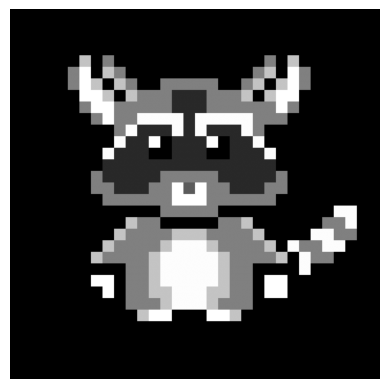

In [1]:
# http://www.pixilart.com/gallery/tags/32x32

# load a png image:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

bild = Image.open("images/racoon.png")
# convert to grayscale:
bild = bild.convert("L")
# display image, but remove axis:
plt.axis('off')  # no axis
plt.imshow(bild, cmap='gray')
plt.show


[[203 198 198 ... 197 197 201]
 [198 195 194 ... 194 194 196]
 [198 195 194 ... 194 194 198]
 ...
 [198 195 194 ... 194 195 199]
 [197 195 194 ... 195 195 197]
 [203 199 199 ... 199 199 201]]
(64, 64)


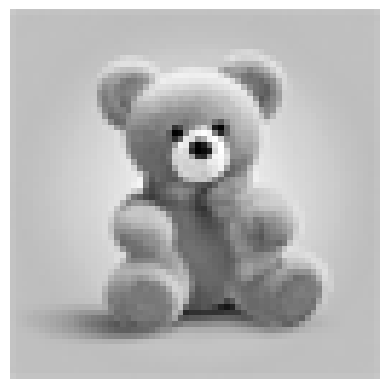

In [10]:
# load a png image:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

bild = Image.open("images/te2.png")
# convert to grayscale:
bild = bild.convert("L")

# rescale to 32x32:
bild = bild.resize((64, 64))
# display image, but remove axis:
plt.axis('off')  # no axis
plt.imshow(bild, cmap='gray')
plt.show
# display the numpy array of the image:
print(np.array(bild))
# pixelbreite des bildes ausgeben:
print(bild.size)

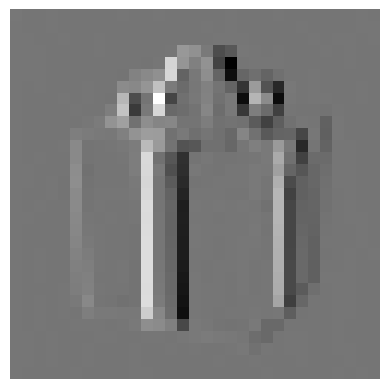

(31, 31)


In [ ]:
# make a 3x3 convolution kernel:
kernel = np.array([[-2, 0, 2],
                   [-2, 0, 2],
                   [-2, 0, 2]])

# apply the convolution kernel to the image:

from scipy.signal import convolve
# convolve the image with the kernel with padding
bild_conv = convolve(bild, kernel, mode='same')

# convolve the image with the kernel without padding:
bild_conv = convolve(np.array(bild), kernel, mode='valid')  # no padding

# convolve the image with the kernel with stride 2:
bild_conv = convolve(np.array(bild), kernel, mode='valid')[::2, ::2]  # stride 2

# display the convolved image:
plt.axis('off')  # no axis
plt.imshow(bild_conv, cmap='gray')
plt.show()
print(bild_conv.shape)

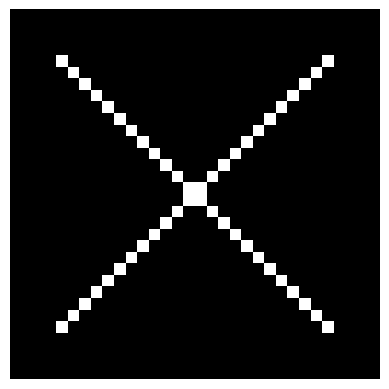

(32, 32)


In [4]:
# make a 32x32 pixel image with all black values:
bild_black = np.zeros((32, 32))
# make a diagonal with white pixels into the image:
for i in range(4,28):
    bild_black[i, i]=255
    bild_black[31-i,i]=255

# display the random image:
plt.axis('off')  # no axis
plt.imshow(bild_black, cmap='gray')
plt.show()
print(bild_black.shape)

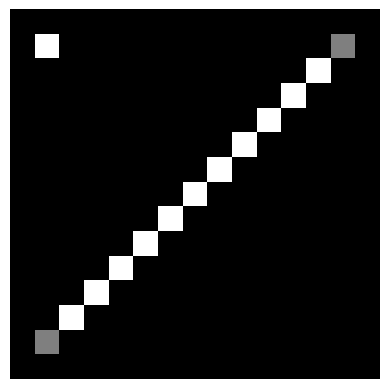

(15, 15)


In [7]:
# make a 3x3 convolution kernel:
kernel = np.array([[2, 1, 0],
                   [1, 0, -1],
                   [0, -1, -2]])

# apply the convolution kernel to the image:
from scipy.signal import convolve

# convolve the image with the kernel with padding
# if values a lower than zero they are set to zero:
bild_conv = convolve(bild_black, kernel, mode='valid')[::2, ::2]  # stride 2
bild_conv[bild_conv < 0] = 0
# if values are higher than 255 they are set to 2
#bild_conv = bild_conv/255

# convolve the image with the kernel without padding:
#bild_conv = convolve(np.array(bild), kernel, mode='valid')  # no padding

# convolve the image with the kernel with stride 2:
#bild_conv = convolve(np.array(bild), kernel, mode='valid')[::2, ::2]  # stride 2

# display the convolved image:
plt.axis('off')  # no axis
plt.imshow(bild_conv, cmap='gray')
plt.show()
print(bild_conv.shape)

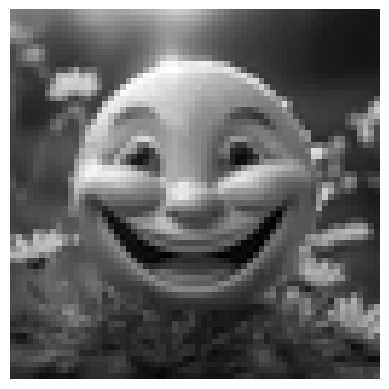

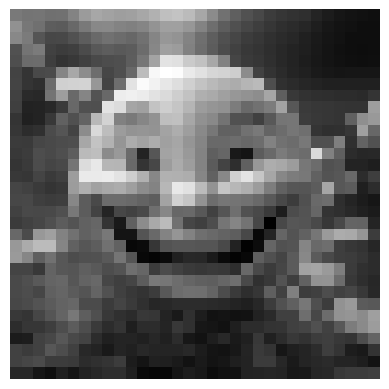

In [9]:
# load a png image:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

bild = Image.open("images/sm2.png")
# convert to grayscale:
bild = bild.convert("L")
# display image, but remove axis:
plt.axis('off')  # no axis
plt.imshow(bild, cmap='gray')
plt.show()

# Function to perform max pooling
def max_pooling(image, pool_size=(3, 3)):
    # Convert image to numpy array
    image_array = np.array(image)
    # Get dimensions of the image
    h, w = image_array.shape
    # Calculate the dimensions of the output
    h_out = h // pool_size[0]
    w_out = w // pool_size[1]
    # Initialize the output array
    pooled_image = np.zeros((h_out, w_out))
    
    # Perform max pooling
    for i in range(h_out):
        for j in range(w_out):
            pooled_image[i, j] = np.average(image_array[i*pool_size[0]:(i+1)*pool_size[0], j*pool_size[1]:(j+1)*pool_size[1]])
    
    return pooled_image

# Apply max pooling
pooled_bild = max_pooling(bild, pool_size=(2, 2))

# Display the pooled image
plt.axis('off')  # no axis
plt.imshow(pooled_bild, cmap='gray')
plt.show()